### Cointegration-based Pairs Trading

In [49]:
#importing relevant libraries

#for maths
import numpy as np

#for data analysis
import pandas as pd

#for data visualisation
import matplotlib.pyplot as plt

#for pulling financial data
import yfinance as yf

#for stats
import statsmodels as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import coint


# Screening

Before making the strategy, we must test for cointegration (is the spread mean-reverting?). The first step is to split the tickers of different stocks into their respective sectors:

In [204]:
sectors = {
    'utilities': ['NEE', 'DUK', 'SO', 'EXC', 'AEP', 'WEC', 'PNW', 'ES', 'LNT', 'PPL', 'DTE', 'CMS', 'AWK', 'WTR', 'NRG'],
    'beverages': ['KO', 'PEP', 'MO', 'KDP', 'MNST'],
    'retail': ['WMT', 'TGT', 'KSS', 'M', 'JWN', 'RH', 'FIVE', 'BBY', 'GPS', 'AZO'],
    'pharma': ['JNJ', 'PFE', 'LLY', 'ABT', 'MRK', 'AMGN', 'GILD', 'VRTX', 'BIIB', 'CRSP', 'REGN', 'BMY'],
    'banking': ['JPM', 'BAC', 'WFC', 'GS', 'MS', 'BLK', 'STT', 'PNC', 'USB', 'RF', 'COF', 'CFG'],
    'energy': ['XOM', 'CVX', 'MPC', 'PSX', 'VLO', 'HES', 'COP', 'EOG', 'MUR', 'OXY', 'SLB'],
    'telecom': ['VZ', 'T', 'TMUS', 'CMCSA', 'CHTR'],
    'insurance': ['UNH', 'HUM', 'CI', 'ELV', 'AXP', 'PGR', 'TMK', 'L', 'AFG', 'HIG', 'WR'],
    'industrials': ['CAT', 'BA', 'MMM', 'LMT', 'RTX', 'GE', 'UTX', 'ITW', 'PH', 'EMR', 'DOV', 'ETN'],
    'consumer_staples': ['PG', 'CLX', 'GIS', 'KMB', 'HSY', 'SJM', 'TAP', 'STZ'],
    'healthcare': ['HCA', 'CVS', 'ABC', 'MCK', 'CAH'],
    'semiconductors': ['QCOM', 'AVGO', 'MU', 'LRCX', 'AMAT'],
    'chemicals': ['LYB', 'APD', 'ECL', 'SHW', 'NEM'],
}

In [205]:
#choosing a start date for checking cointegration
start_date = '2017-01-01'

To check for cointegration I fit each pair to a linear regression model, find the spread, and run an Augmented Dickey-Fuller Test, rejecting the null hypothesis (the pair is not cointegrated) if a p-value of below 0.05 is obtained. The successful pairs are then displayed with their p-values

In [206]:
successes = []
successful_tickers = []
for sector, tickers in sectors.items():
    print(f'Testing sector: {sector}')
    df = yf.download(tickers, start = start_date, interval = '1d')['Close']

    for i in range(len(tickers)):
        for j in range(i+1, len(tickers)):
            stock_1 = tickers[i]
            stock_2 = tickers[j]

            try:
                stock_1_dropna = df[tickers[i]].dropna()
                stock_2_dropna = df[tickers[j]].dropna()

                aligned = pd.concat([stock_1_dropna, stock_2_dropna], axis = 1, sort=False).dropna()

                beta = np.polyfit(aligned[stock_2], aligned[stock_1], 1)[0]
                spread = df[stock_1] - beta * df[stock_2]

            
                p_value = adfuller(spread.dropna(), autolag = 'AIC', result_object = False)[1]

                
                if p_value < 0.05:
                    
                    print(f'{stock_1} and {stock_2} are cointegrated with a p-value of {p_value}')
                    successes.append({
                        'tickers': f'{stock_1}/{stock_2}',
                        'p_value': p_value
                        })
                    successful_tickers.append([stock_1, stock_2])
            except:
                pass
results = pd.DataFrame(successes)
print(results)

[                       0%                       ]

Testing sector: utilities


[**********            20%                       ]  3 of 15 completed$WTR: possibly delisted; no timezone found
[*********************100%***********************]  15 of 15 completed

1 Failed download:
['WTR']: possibly delisted; no timezone found


NEE and WEC are cointegrated with a p-value of 0.02882077324915334
DUK and SO are cointegrated with a p-value of 0.016223724842711076
DUK and LNT are cointegrated with a p-value of 0.03450267558755978
DUK and DTE are cointegrated with a p-value of 4.383431916032594e-05
WEC and LNT are cointegrated with a p-value of 0.04458841247771445
PNW and PPL are cointegrated with a p-value of 0.017286327874378594
PNW and NRG are cointegrated with a p-value of 0.0041458915212258095
ES and AWK are cointegrated with a p-value of 0.04450997845132952
PPL and NRG are cointegrated with a p-value of 0.0007455478498880433
CMS and NRG are cointegrated with a p-value of 0.04036022532212329
Testing sector: beverages


[*********************100%***********************]  5 of 5 completed
[                       0%                       ]

...

Testing sector: semiconductors


[*********************100%***********************]  5 of 5 completed
[                       0%                       ]

Testing sector: chemicals


[*********************100%***********************]  5 of 5 completed


APD and SHW are cointegrated with a p-value of 0.01681897248766857
       tickers   p_value
0      NEE/WEC  0.028821
1       DUK/SO  0.016224
2      DUK/LNT  0.034503
3      DUK/DTE  0.000044
4      WEC/LNT  0.044588
5      PNW/PPL  0.017286
6      PNW/NRG  0.004146
7       ES/AWK  0.044510
8      PPL/NRG  0.000746
9      CMS/NRG  0.040360
10     TGT/BBY  0.011490
11    LLY/AMGN  0.001136
12    LLY/VRTX  0.022463
13    ABT/BIIB  0.032683
14      BAC/GS  0.015181
15      BAC/MS  0.016207
16     BAC/BLK  0.026326
17     BAC/PNC  0.000668
18      BAC/RF  0.040260
19     BAC/COF  0.039207
20      GS/CFG  0.021268
21       MS/RF  0.007010
22      MS/CFG  0.041302
23     BLK/PNC  0.036362
24      BLK/RF  0.024007
25     BLK/COF  0.005631
26     USB/CFG  0.023797
27     XOM/CVX  0.024035
28     MPC/PSX  0.009499
29     PSX/VLO  0.046024
30     OXY/SLB  0.028495
31  CMCSA/CHTR  0.036424
32     UNH/ELV  0.001172
33      HUM/WR  0.020431
34       CI/WR  0.000472
35      ELV/WR  0.008039
36      

Once I have a shortlist in order to check further which pair are viable I use a portion of the stocks' histories (70%) to train the linear regression model and then use the rest of the data for an ADF test. The successful results are shown below

In [207]:
def time_split(x, train_size= 0.7):
    i = int(len(x) * train_size)
    return x[:i].copy(), x[i:].copy()

In [208]:
walk_forward = []
for pair in successful_tickers:
    t1 = pair[0]
    t2 = pair[1]

    df = yf.download([t1, t2], start = start_date, interval = '1d')['Close'].dropna()
    df_train, df_test = time_split(df, train_size = 0.7)

    beta = np.polyfit(df_train[t2], df_train[t1], 1)[0] # finding beta for training data

    print('Tickers:', t1, t2)

    #running adf test for training data
    training_spread = df_train[t1] - beta * df_train[t2] 
    training_p_value = adfuller(training_spread.dropna(), autolag = 'AIC', result_object = False)[1]
    #print(f'training: \np-value: {training_p_value} \ncointegrated: {training_p_value < 0.05}')

    #running adf test for test data
    testing_spread = df_test[t1] - beta * df_test[t2] 
    testing_p_value = adfuller(testing_spread.dropna(), autolag = 'AIC', result_object = False)[1]
    #print(f'test: \np-value: {testing_p_value} \ncointegrated: {testing_p_value < 0.05}')

    #test coint p value
    score, coint_p_value, crit_values = coint(df[t1], df[t2])

    if training_p_value < 0.05 and testing_p_value < 0.05:
        walk_forward.append({'Tickers': f'{t1}/{t2}',
                            'training_p_value': training_p_value,
                            'testing_p_value': testing_p_value,
                            'training_pass': training_p_value < 0.05,
                            'testing_pass': testing_p_value < 0.05,
                            'coint_p_value': coint_p_value
                            })
walk_forward_results = pd.DataFrame(walk_forward)
walk_forward_results

[*********************100%***********************]  2 of 2 completed


Tickers: NEE WEC


[*********************100%***********************]  2 of 2 completed


Tickers: DUK SO


[*********************100%***********************]  2 of 2 completed


...

[*********************100%***********************]  2 of 2 completed


Tickers: HCA MCK


[*********************100%***********************]  2 of 2 completed


Tickers: APD SHW


,Tickers,training_p_value,testing_p_value,training_pass,testing_pass,coint_p_value
0,DUK/LNT,0.039558,0.013667,True,True,0.109080
1,DUK/DTE,0.000857,0.003240,True,True,0.000308
2,AXP/HIG,0.037562,0.031660,True,True,0.000503


After this testing, I choose a pair and then run a final test by adjusting the amount of data on which the model is trained/ tested.

In [209]:
pair = ['DUK', 'DTE']

In [210]:

t1 = pair[0]
t2 = pair[1]

df_final_walkforward = yf.download([t1, t2], start = start_date, interval = '1d')['Close']
df_walkforward_train, df_walkforward_test = time_split(df_final_walkforward, train_size = 0.6)
training_beta = np.polyfit(df_walkforward_train[t2], df_walkforward_train[t1], 1)[0] # finding training_beta for training data

print('Tickers:', t1, t2)

#running adf test for training data
training_spread = df_walkforward_train[t1] - training_beta * df_walkforward_train[t2] 
training_p_value = adfuller(training_spread.dropna(), autolag = 'AIC', result_object = False)[1]
print(f'training: \np-value: {training_p_value} \ncointegrated: {training_p_value < 0.05}')

#running adf test for test data
testing_spread = df_walkforward_test[t1] - training_beta * df_walkforward_test[t2] 
testing_p_value = adfuller(testing_spread.dropna(), autolag = 'AIC', result_object = False)[1]
print(f'test: \np-value: {testing_p_value} \ncointegrated: {testing_p_value < 0.05}')

[*********************100%***********************]  2 of 2 completed

Tickers: DUK DTE
training: 
p-value: 0.007368020787077217 
cointegrated: True
test: 
p-value: 0.031209442810430723 
cointegrated: True


Here I download and split the data in order to find the beta which I will use for the actual model. While developing the model I experimented with a rolling beta but decided against it after extended testing, as the rolling beta would overfit and cause problems. It may work with other pairs, but it didn't in this case.

In [211]:

df = yf.download(pair, start = start_date, interval = '1d')['Close'].dropna()

split_boundary = 0.8

df_train, df_test = time_split(df, train_size = split_boundary)
pnl_beta = np.polyfit(df_train[pair[1]], df_train[pair[0]], 1)[0] 

test_sample_size = len(df_test)

df['spread'] = df[pair[0]] - pnl_beta * df[pair[1]]

[*********************100%***********************]  2 of 2 completed


<Axes: xlabel='Date'>

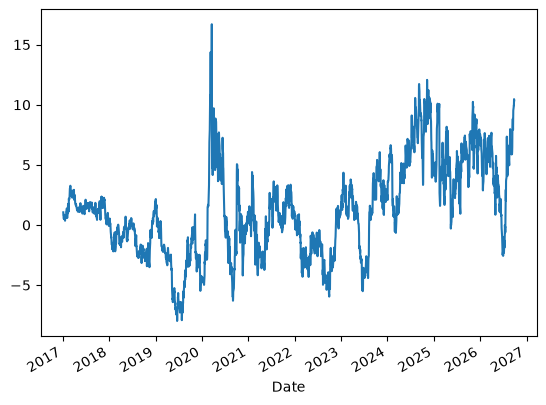

In [212]:
df['spread'].plot()

This calculation assumes that the rate of reversion back to the mean is proportional to the distance from the mean. It  finds the averge half-life of decay back to the mean which is used to find a suitable window for looking back and finding the rolling mean and standard deviation

In [213]:
df['spread_lag_1'] = df['spread'].shift()
df = df.dropna()
df['delta_spread'] = df['spread'] - df['spread_lag_1']

lam = - np.polyfit(df['spread_lag_1'], df['delta_spread'], 1)[0]

half_life =  np.log(2) / lam

print(f'half life: {half_life}')


half life: 48.49687149241835


In [214]:
lookback_window = int(round(2.5* half_life, 2))

In [215]:
df['rolling_spread_mean'] = df['spread'].rolling(lookback_window).mean()
df['rolling_spread_std'] = df['spread'].rolling(lookback_window).std()
df = df.dropna()

The Z score is the number of standard deviations away from the mean the stock is at a given time. The strategy is simple: if |z| > 2 the spread is expected to revert to the mean, so short one stock and long the other. I exit my position when |z| < 0.2 to avoid holding for too long

In [216]:
n1 = 2 #n1 is the number of standard deviations away from me mean a buy/ sell signal will occur

df['z_score'] = (df['spread'] - df['rolling_spread_mean']) / df['rolling_spread_std']



outside_instances = 0
for i in range(len(df)):
    if np.abs(df['z_score'].iloc[i]) > n1:
        outside_instances += 1

pct_outside = outside_instances / len(df) * 100
print(f'pct outside of 2sigma bands is {pct_outside}')



pct outside of 2sigma bands is 11.78494623655914


In [217]:
positions = []
changes = []
current_position = 0
position_change = 0
for i in range(len(df)):
    if df['z_score'].iloc[i] > n1 and current_position != -1:
        current_position = -1
        position_change = 1
    elif df['z_score'].iloc[i] < -n1 and current_position != 1:
        current_position = 1
        position_change = 1
    elif df['z_score'].iloc[i] > -0.2 and current_position == 1:
        current_position = 0
        position_change = 1
    elif df['z_score'].iloc[i] < 0.2 and current_position == -1:
        current_position = 0
        position_change = 1
    else:
        position_change = 0
    positions.append(current_position)
    changes.append(position_change)

df['position'] = positions
df['changes'] = changes
df['total_changes'] = df['changes'].cumsum()
print(f'number of transactions: {df['changes'].sum()}')

number of transactions: 63


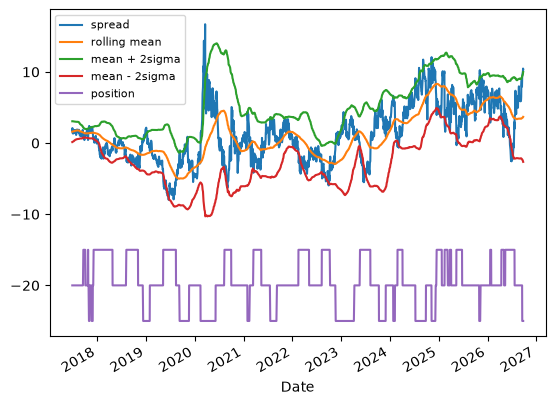

In [218]:
#visualising how much is inside and outside of and +- nsigma band
upper = df['rolling_spread_mean'] + n1 * df['rolling_spread_std']
lower = df['rolling_spread_mean'] - n1 * df['rolling_spread_std']

df['spread'].plot()
df['rolling_spread_mean'].plot(label = 'rolling mean')
(upper).plot(label = 'mean + 2sigma')
(lower).plot(label = 'mean - 2sigma')
(5 * df['position'] - 20).plot()
plt.legend(prop = {'size': 8})

Finally here's the backtest: I test the model on the data from which I have not calculated beta, calculate the log returns, annualised returns, annualised sharpe, and the number of transactions it has run.

annualised_sharpe: 2.05
annualised returns: 14.4%
no. of transactions tested: 19


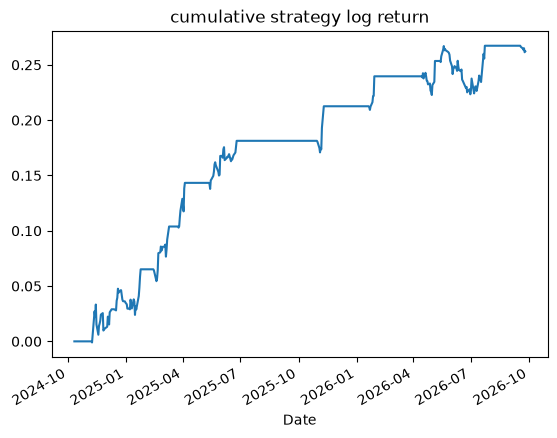

In [219]:
df_final_test = df.iloc[len(df)-test_sample_size:].copy()

df_final_test['t1_log_returns'] = np.log(df_final_test[pair[0]] / df_final_test[pair[0]].shift())
df_final_test['t2_log_returns'] = np.log(df_final_test[pair[1]] / df_final_test[pair[1]].shift())

daily_returns = [0]
transactions = 0
for i in range(1, len(df_final_test)):
    if df_final_test['position'].shift().iloc[i] == 1:
        ret = df_final_test['t1_log_returns'].iloc[i] - pnl_beta * df_final_test['t2_log_returns'].iloc[i]
    elif df_final_test['position'].shift().iloc[i] == -1:
        ret = - df_final_test['t1_log_returns'].iloc[i] + pnl_beta * df_final_test['t2_log_returns'].iloc[i]
    elif df_final_test['position'].shift().iloc[i] == 0:
        ret = 0
    daily_returns.append(ret)
    
df_final_test['strategy_return'] = daily_returns
df_final_test['strategy_return'] = df_final_test['strategy_return'] - df_final_test['changes'] * 0.0005 * 2 # transaction costs approximated using each transaction is 5 basis points and then using the taylor approximation ln(1-c =~ -c)
df_final_test['cum_log_returns'] = df_final_test['strategy_return'].cumsum()
df_final_test['cum_log_returns'].plot(title='cumulative strategy log return')
annualised_sharpe = df_final_test['strategy_return'].mean() / df_final_test['strategy_return'].std() * np.sqrt(252)
annualised_log_returns = df_final_test['strategy_return'].mean() * 252
print(f'annualised_sharpe: {annualised_sharpe:.2f}\nannualised returns: {(np.exp(annualised_log_returns) - 1) * 100:.1f}%\nno. of transactions tested: {df_final_test['changes'].sum()}')


The sample size is quite small, but where this model has traded it has been successful.

### Conclusion

This project taught me a lot about trading strategies and how to build them. The model is built so that you can feed in stocks from a given sector and see whether a fixed-beta pairs trading strategy would work, and had I more time I would have tested far more pairs to find a pair which successfully mean-reverts with a rolling beta. There are some limitations - flipping the pair order changes how beta is calculated and used and so yields different results. I have not implemented a stop loss, and although the spread has stayed comfortably in bounds in the chosen region this could cause issues in the future. The sample size was small and the strategy could be improved, however building this framework was fascinating and revealed to me how much more there is to know about trading.